In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import matplotlib.ticker as ticker

#  STEP 1: Set your file path 
file_path = "void_halo_0.hdf5"

#  STEP 2: Open the file 
with h5py.File(file_path, "r") as f:

    #  STEP 3: Show top-level structure 
    print("\nTop-level keys (halo names):")
    halo_names = list(f.keys())
    print(halo_names)

    #  STEP 4: Choose a halo 
    halo = f[halo_names[0]]   # take the first halo
    print(f"\nExploring {halo_names[0]}...")

    #  STEP 5: Show contents of the halo 
    print("\nDatasets in this halo:")
    print(list(halo.keys()))

    print("\nAttributes of this halo:")
    print(list(halo.attrs.keys()))




Top-level keys (halo names):
['halo_0']

Exploring halo_0...

Datasets in this halo:
['SED_flux', 'SED_flux_density', 'SED_flux_density_with_noise', 'SED_flux_with_noise', 'SED_wav_angstroms', 'SED_wav_angstroms_with_noise', 'SED_wav_microns', 'SED_wav_microns_with_noise', 'Salpeter_IMF_SFR', 'Salpeter_IMF_SFR_with_noise', 'UV_continuum_slope', 'UV_continuum_slope_error', 'UV_continuum_slope_error_with_noise', 'UV_continuum_slope_with_noise', 'absolute_magnitude_UV', 'absolute_magnitude_UV_with_noise', 'angular_momentum', 'apparent_magnitude', 'apparent_magnitude_with_noise', 'bh_particle_IDs', 'color_band', 'color_band_with_noise', 'emission_lines', 'gas_mass', 'half_light_rad', 'half_light_rad_with_noise', 'image', 'image_with_noise', 'pop2_metallicity_fraction', 'pop2_stellar_age', 'pop2_stellar_angular_momentum', 'pop2_stellar_masses', 'pop2_stellar_positions', 'pop2_stellar_velocities', 'pop3_stellar_masses', 'position', 'sersic_error', 'sersic_error_with_noise', 'sersic_index', 

In [3]:
#INTERESTING HALO PLOTS#

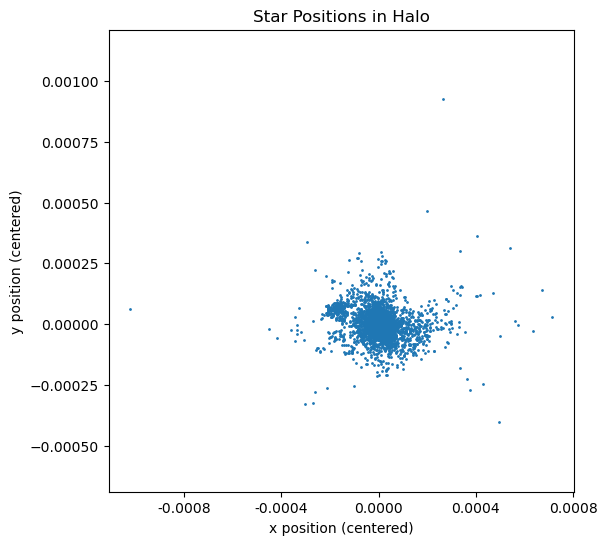

In [19]:
#  PLOT STAR POSITIONS IN HALO 
# Shows the spatial distribution of stars in the halo (2D projection)

file_path = "void_halo_0.hdf5"

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

    # Select the first halo in the file
    halo = f[list(f.keys())[0]]

    # Load stellar positions (shape: N_particles × 3 → x, y, z)
    positions = halo["pop2_stellar_positions"][:]

    # Extract x and y coordinates (projecting 3D → 2D plane)
    x = positions[:, 0]
    y = positions[:, 1]

    # Center the galaxy by subtracting the mean position
    # This moves the center of the halo to (0, 0)
    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)

    # Create a square figure
    plt.figure(figsize=(6,6))

    # Scatter plot: each point represents one star particle
    # s=1 keeps points small since there are many stars
    plt.scatter(x_centered, y_centered, s=1)

    # Keep equal scaling so the galaxy shape is not distorted
    plt.axis("equal")

    # Axis labels
    plt.xlabel("x position (centered)")
    plt.ylabel("y position (centered)")

    # Plot title
    plt.title("Star Positions in Halo")

    # Reduce number of tick marks for cleaner appearance
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))

    # Format tick labels to avoid long decimals
    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    # Display the plot
    plt.show()

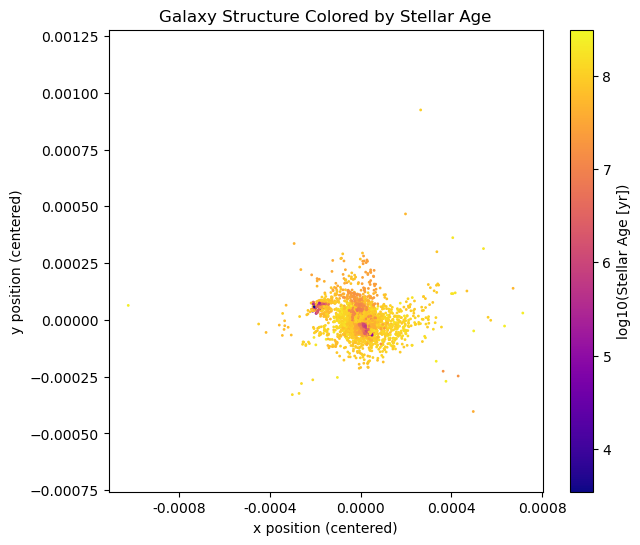

In [18]:
#  STELLAR STRUCTURE COLORED BY AGE 
# Visualizes spatial distribution of stars in the halo,
# with color representing stellar age

file_path = "void_halo_0.hdf5"

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

    # Select the first halo in the file (in this case there is only one halo)
    halo = f[list(f.keys())[0]]

    # Load stellar positions (shape: N_particles × 3 → x, y, z)
    positions = halo["pop2_stellar_positions"][:]

    # Load stellar ages (in years)
    ages = halo["pop2_stellar_age"][:]

    # Extract x and y positions (projecting 3D → 2D plane)
    x = positions[:, 0]
    y = positions[:, 1]

    # Center the galaxy by subtracting the mean position
    # (moves the galaxy center to ~0,0 for cleaner visualization)
    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)

    # Create figure
    plt.figure(figsize=(7,6))

    # Scatter plot of star positions
    # Each point = one star particle
    # Color = stellar age
    plt.scatter(
        x_centered,
        y_centered,
        c=log_age,        # color by age
        s=1,              # very small points (many particles)
        cmap="plasma"     # color map
    )

    # Add colorbar to interpret age values
    cbar = plt.colorbar()
    cbar.set_label("log10(Stellar Age [yr])")

    # Axis labels
    plt.xlabel("x position (centered)")
    plt.ylabel("y position (centered)")

    # Title
    plt.title("Galaxy Structure Colored by Stellar Age")

    # Limit number of tick marks for cleaner look
    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))
    plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))

    # Keep equal scaling so galaxy shape is not distorted
    plt.axis("equal")

    # Show plot
    plt.show()

Filters: ['F150W', 'F200W', 'F277W', 'F356W', 'F444W']


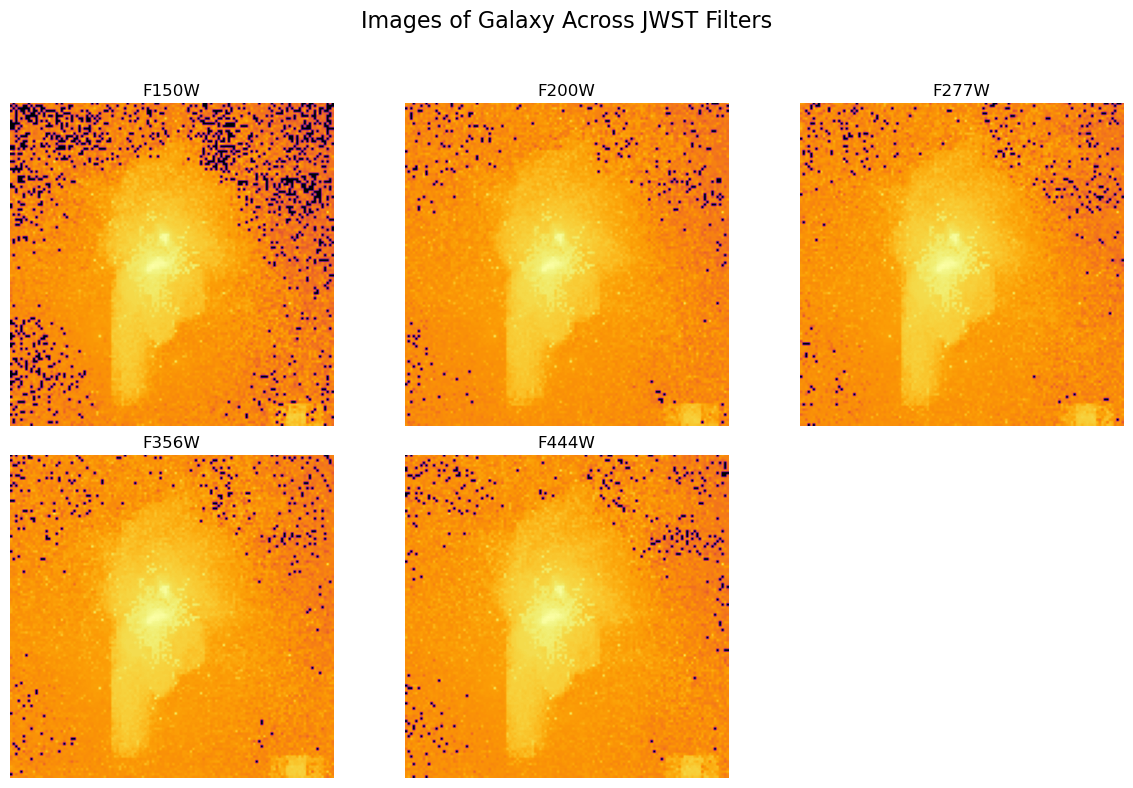

In [16]:
#  PRINTING IMAGES ACROSS FILTERS 
# Visualizes simulated images of a halo in different JWST telescope filters

file_path = "void_halo_0.hdf5"   # Path to halo file

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

    # Select the first halo in the file (in this case there is only one halo)
    halo = f[list(f.keys())[0]]

    # Access the image group (contains one image per filter)
    image_group = halo["image"]

    # Get list of filters (e.g., F150W, F200W, etc.)
    filters = list(image_group.keys())

    print("Filters:", filters)

    # Set up grid layout for plotting
    n = len(filters)                 # total number of images
    cols = 3                         # number of columns
    rows = int(np.ceil(n / cols))    # compute rows needed

    # Create figure sized to fit all images
    plt.figure(figsize=(12, 4 * rows))

    # Loop over each filter and plot its image
    for i, filt in enumerate(filters):

        # Load image data
        img = image_group[filt][:]

        # Apply log scaling to enhance faint features
        img_log = np.log10(img + 1e-10)

        # Create subplot
        plt.subplot(rows, cols, i + 1)

        # Display image
        plt.imshow(img_log, origin="lower", cmap="inferno")

        # Label with filter name
        plt.title(filt)

        # Remove axes for cleaner visualization
        plt.axis("off")

    # Overall title
    plt.suptitle("Images of Galaxy Across JWST Filters", fontsize=16)

    # Adjust spacing so title doesn't overlap plots
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Show figure
    plt.show()

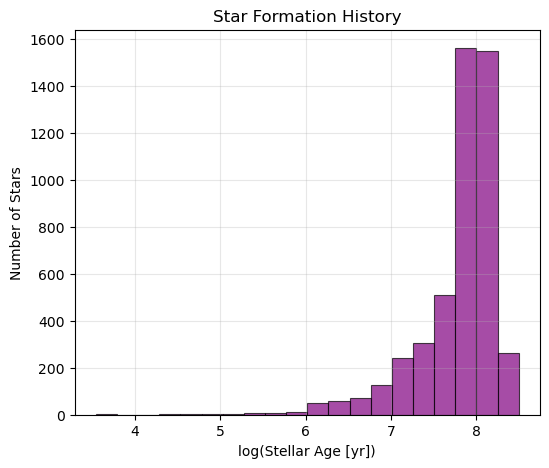

In [13]:
#  STAR FORMATION HISTORY HISTOGRAM PLOT 

file_path = "void_halo_0.hdf5"   # Path to the halo file

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

    # Select the first halo in the file (in this case there is only one halo)
    halo = f[list(f.keys())[0]]

    # Load stellar ages (Population II stars) in years
    ages = halo["pop2_stellar_age"][:]

    # Convert ages to log10 scale (better for wide ranges)
    log_ages = np.log10(ages)

    # Create the plot
    plt.figure(figsize=(6,5))

    # Plot histogram of stellar ages
    plt.hist(
        log_ages,
        bins=20,                 # fewer bins → smoother histogram
        color="purple",          # bar color
        alpha=0.7,               # transparency
        edgecolor="black",       # outline around each bin
        linewidth=0.8            # thickness of outline
    )

    # Axis labels
    #in astrophysics log10 is the assumed log base
    plt.xlabel("log(Stellar Age [yr])")
    plt.ylabel("Number of Stars")

    # Plot title
    plt.title("Star Formation History")

    # Light grid for readability
    plt.grid(alpha=0.3)

    # Show the plot
    plt.show()